## Protein Expression Plots

#### Protein Data Load

In [2]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
# expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values # Note that the Y acis is inverted. This is done to standardize with RNA plots

In [19]:
import importlib
import my_functions
importlib.reload(my_functions)

x=my_functions.average_cell_counts(adata, 1, 1, "radius", 21)
display(x)

[NbConvertApp] Converting notebook my_functions.ipynb to python
[NbConvertApp] Writing 24127 bytes to my_functions.py


{'Total Cell Counts':            Neutrophils  Endothelial_cells  Plasma_cells  Monocytes  \
 Sample ID                                                            
 c_1_1              214                290            71         16   
 
            Tumor_cells  Fibroblasts/SMCs  Macrophages  B_cells  CD4+T_cells  \
 Sample ID                                                                     
 c_1_1              200                60            6        2            2   
 
            Total Cell Count  
 Sample ID                    
 c_1_1                   861  ,
 'Cell Type Percentages':            Neutrophils  Endothelial_cells  Plasma_cells  Monocytes  \
 Sample ID                                                            
 c_1_1         24.85482          33.681765      8.246225   1.858304   
 
            Tumor_cells  Fibroblasts/SMCs  Macrophages   B_cells  CD4+T_cells  
 Sample ID                                                                     
 c_1_1        23.228804     

#### Plot Protein Expression Spatially

This code creates two plots for a given input:
1. A graph of the cells present in the sample
2. A graph of the expression of a particular gene spatially


### Baseline Plot of the Immune Cells

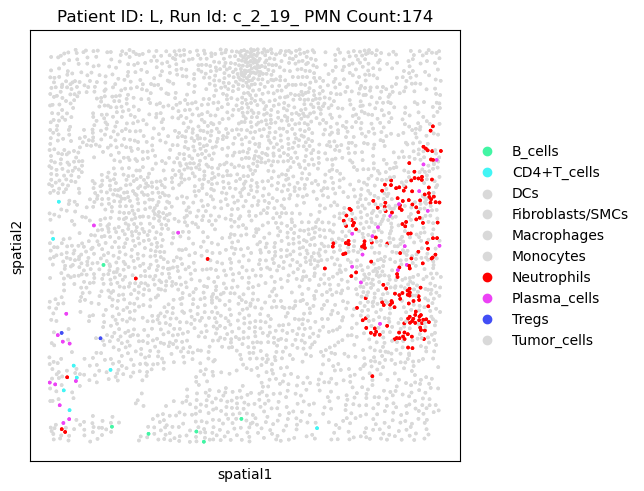

In [5]:
import squidpy as sq
import warnings
import my_functions
warnings.filterwarnings("ignore")

# Color scheme
NEUTROPHIL_COLOR = "#ff0000"
BCELL_COLOR = "#42f5a4"
CD4_COLOR = "#42f5f5"
CD8_COLOR = "#4248f5"
DCs_COLOR = "#d9d9d9"
FIBROBLASTS_COLOR = "#d9d9d9"
MACROPHAGE_COLOR = "#d9d9d9"
MONOCYTES_COLOR = "#d9d9d9"
NK_COLOR = "#d9d9d9"
PLASMA_COLOR = "#ec42f5"
TREG_COLOR = "#424ef5"
TUMOR_COLOR = "#d9d9d9"
OTHER_COLOR = "#d9d9d9"

# Full color mapping
cell_type_colors = {
    "Neutrophils": NEUTROPHIL_COLOR,
    "B_cells": BCELL_COLOR,
    "CD4+T_cells": CD4_COLOR,
    "CD8+T_cells": CD8_COLOR,
    "DCs": DCs_COLOR,
    "Fibroblasts/SMCs": FIBROBLASTS_COLOR,
    "Macrophages": MACROPHAGE_COLOR,
    "Monocytes": MONOCYTES_COLOR,
    "NK_cells": NK_COLOR,
    "Plasma_cells": PLASMA_COLOR,
    "Tregs": TREG_COLOR,
    "Tumor_cells": TUMOR_COLOR
}

cell_ID_like="c_2_19_"

#cell_ID_like = f"c_{j}_{i}_"
subset = adata[adata.obs.cell_ID.str.contains(cell_ID_like)]
pmn_count=my_functions.pmn_counter(adata, cell_ID_like)["PMN Count"]

patient_id = subset.obs["Patient.ID"].unique()[0]

# Convert to categorical without setting all 12 types
subset.obs["merged_annot_cluster"] = subset.obs["merged_annot_cluster"].astype("category")

# Get the actual order of categories used in the subset
category_order = subset.obs["merged_annot_cluster"].cat.categories.tolist()

# Generate color list in the exact same order
color_list = [
    cell_type_colors.get(ct, OTHER_COLOR)
    for ct in category_order
]

# Set the colors in the correct order
subset.uns["merged_annot_cluster_colors"] = color_list

# Plot with assigned colors
sq.pl.spatial_scatter(
    subset,
    shape=None,
    color="merged_annot_cluster",
    size=10,
    title=f"Patient ID: {patient_id}, Run Id: {cell_ID_like} PMN Count:{pmn_count}"
        )

### Gene Expression Plot Grey Map

This function allows you to specify a protein and it will show a map of it's expression in a light/dark manner. 

Input:
* TMA/Sample Id
* Mapping Gene

Output:
* Greyscale graph of gene expression

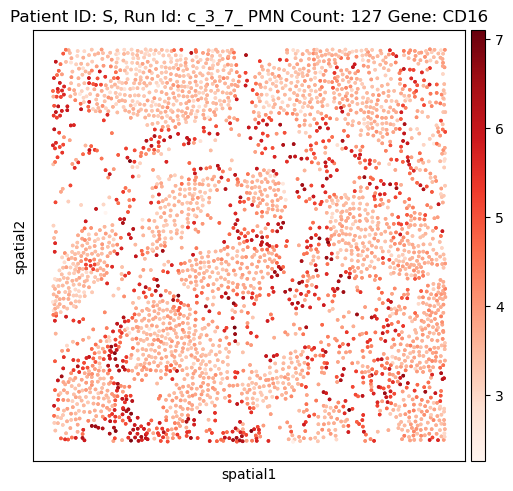

In [5]:
import squidpy as sq
import warnings
import my_functions
warnings.filterwarnings("ignore")

cell_ID_like="c_3_7_"
mapping_gene="CD16"

subset = adata[adata.obs.cell_ID.str.contains(cell_ID_like)]
pmn_count = my_functions.pmn_counter(adata, cell_ID_like)["PMN Count"]
patient_id = subset.obs["Patient.ID"].unique()[0]

# Convert to categorical without setting all 12 types
subset.obs["merged_annot_cluster"] = subset.obs["merged_annot_cluster"].astype("category")

# Get gene expression and store in obs
gene_values = subset[:, mapping_gene].X
if hasattr(gene_values, "toarray"):  # handle sparse matrix
    gene_values = gene_values.toarray().flatten()
else:
    gene_values = gene_values.flatten()

subset.obs[f"{mapping_gene}_expression"] = gene_values

# Plot using gene expression as color
sq.pl.spatial_scatter(
    subset,
    shape=None,
    color=f"{mapping_gene}_expression",
    size=10,
    cmap="Reds",  # optional: you can change color map
    title=f"Patient ID: {patient_id}, Run Id: {cell_ID_like} PMN Count: {pmn_count} Gene: {mapping_gene}"
)

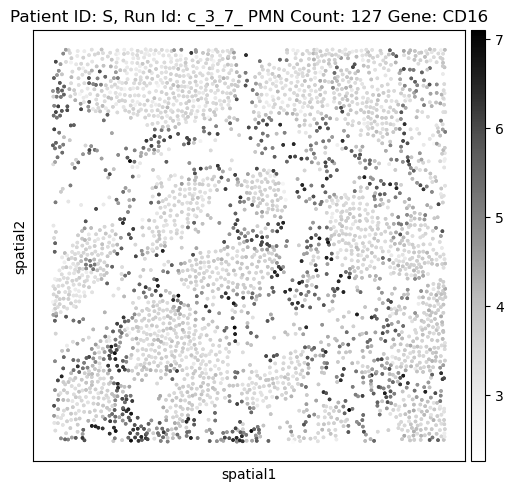

In [3]:
import squidpy as sq
import warnings
import my_functions
warnings.filterwarnings("ignore")

cell_ID_like="c_3_7_"
mapping_gene="CD16"

subset = adata[adata.obs.cell_ID.str.contains(cell_ID_like)]
pmn_count = my_functions.pmn_counter(adata, cell_ID_like)["PMN Count"]
patient_id = subset.obs["Patient.ID"].unique()[0]

# Convert to categorical without setting all 12 types
subset.obs["merged_annot_cluster"] = subset.obs["merged_annot_cluster"].astype("category")

# Get gene expression and store in obs
gene_values = subset[:, mapping_gene].X
if hasattr(gene_values, "toarray"):  # handle sparse matrix
    gene_values = gene_values.toarray().flatten()
else:
    gene_values = gene_values.flatten()

subset.obs[f"{mapping_gene}_expression"] = gene_values

# Plot using gene expression as color
sq.pl.spatial_scatter(
    subset,
    shape=None,
    color=f"{mapping_gene}_expression",
    size=10,
    cmap="Greys",  # optional: you can change color map
    title=f"Patient ID: {patient_id}, Run Id: {cell_ID_like} PMN Count: {pmn_count} Gene: {mapping_gene}"
)